<a href="https://colab.research.google.com/github/galardhia/Sentiment_Analysis-Google_Colab-Whoosh/blob/main/IndoBERT_Sentiment_Analysis_WHOOSH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



**ANALISIS SENTIMEN PROYEK KERETA CEPAT WHOOSH MENGGUNAKAN TEXT EMBEDDING INDOBERT DENGAN PERBANDINGAN KLASIFIKATOR XGBOOST DAN SGDCLASSIFIER**

1. Setup: Menginstal dan mengimpor semua library yang dibutuhkan.
2. Data: Load Dataset.
3. Pre-processing: Membersihkan teks, mengubah ke huruf kecil (case folding), dan normalisasi slang.
4. Labelling Otomatis: Memberi label sentimen (positif, negatif, netral) secara otomatis menggunakan model Zero-Shot dari Hugging Face.
5. Feature Extraction: Mengubah teks bersih menjadi vektor angka berdimensi 768 menggunakan IndoBERT.
6. Data Splitting & Scaling: Membagi data menjadi set latih dan uji, lalu menyamakan skala fiturnya.
7. Training & Evaluation: Melatih model XGBoost dan SGDClassifier, lalu mengevaluasi performanya.
8. Visualization: Menampilkan hasil evaluasi dalam bentuk confusion matrix.




Langkah 1: Instalasi & Setup Library

In [ ]:
# Instalasi library yang diperlukan
!pip install transformers torch pandas scikit-learn xgboost seaborn matplotlib numpy -q

In [ ]:
# Impor semua library yang akan digunakan
import pandas as pd
import numpy as np
import re
import torch
import seaborn as sns
import matplotlib.pyplot as plt

# Transformers (Hugging Face)
from transformers import pipeline, AutoTokenizer, AutoModel

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Models
from xgboost import XGBClassifier
from sklearn.linear_model import SGDClassifier

# Pengaturan untuk tampilan
pd.set_option('display.max_colwidth', None)
sns.set_style('whitegrid')

Langkah 2: Memuat Data

---------upload file 'whoosh_all_2023_until_2025_fix.csv' terlebih dahulu

In [ ]:
df = pd.read_csv('whoosh_all_2023_until_2025_fix.csv')

# Tampilkan data awal
print("Data Awal:")
df.head()

Data Awal:


,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1975259914072408299,Mon Oct 06 18:00:36 +0000 2025,0,Kalo dipikir-pikir aga absurd juga ya. Dari cgk mau ke bandung via keretaan harus pake ka bandara-lrt-whoosh. Estimasi waktu dari bandara sampe pdlrng sekitar 120 menit. Biaya total 340an. Sedangkan naik shuttle langsung dari pintu keluar bandara 195rbu cuman lebih lama sejam,1975259914072408299,NaN,NaN,in,NaN,0,1,0,https://x.com/undefined/status/1975259914072408299,225290554,NaN
1,1975189374880125429,Mon Oct 06 15:32:13 +0000 2025,1,@Outstandjing Orang Malaysia mau liburan ke Bandung malah disuruh landing di Majalengka. Pantes sekarang pada milih landing Jakarta trus lanjut Whoosh.,1975222569843441916,NaN,Outstandjing,in,NaN,0,0,0,https://x.com/undefined/status/1975222569843441916,1777176481493610496,NaN
2,1975218070059970620,Mon Oct 06 15:14:22 +0000 2025,0,2. Transportasi Publik Modern * MRT Jakarta Fase 1 (Lebak Bulus Bundaran HI). * LRT Jabodebek. * Kereta Cepat Jakarta Bandung (Whoosh). * Pembangunan Bandara baru seperti Yogyakarta International Airport (YIA) dan perluasan bandara di berbagai daerah.,1975218078058525078,NaN,Sahrul357,in,NaN,0,1,0,https://x.com/undefined/status/1975218078058525078,1958145200267898880,NaN
3,1975217518223728803,Mon Oct 06 15:12:08 +0000 2025,0,Kangen ke bandung naik whoosh,1975217518223728803,NaN,NaN,in,NaN,0,0,0,https://x.com/undefined/status/1975217518223728803,1261795639773421568,NaN
4,1975179655562043448,Mon Oct 06 14:57:55 +0000 2025,4,@AnnaCharel27779 @NenkMonica Lah kasus Hambalang udah selesai begok lu tersangkanya juga udah di tangkap yg sekarang perlu di usut proyek jaman jokowi kcic bandara kertajati mandalika ikn vdan banyak lagi,1975213939341566119,NaN,AnnaCharel27779,in,NaN,0,2,0,https://x.com/undefined/status/1975213939341566119,1478463430986121218,NaN


In [ ]:
# Tampilkan ringkasan DataFrame
print("\nInfo Lengkap DataFrame:")
df.info()


Info Lengkap DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5011 entries, 0 to 5010
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   conversation_id_str      5011 non-null   int64  
 1   created_at               5011 non-null   object 
 2   favorite_count           5011 non-null   int64  
 3   full_text                5011 non-null   object 
 4   id_str                   5011 non-null   int64  
 5   image_url                1184 non-null   object 
 6   in_reply_to_screen_name  2242 non-null   object 
 7   lang                     5011 non-null   object 
 8   location                 0 non-null      float64
 9   quote_count              5011 non-null   int64  
 10  reply_count              5011 non-null   int64  
 11  retweet_count            5011 non-null   int64  
 12  tweet_url                5011 non-null   object 
 13  user_id_str              5011 non-null   int64  
 14 

Cek dan hapus duplikat data sebelum cleaning

In [ ]:
import pandas as pd
import re

# HAPUS DUPLIKAT berdasarkan kolom 'id_str'
# .drop_duplicates() akan menyimpan baris pertama yang ditemui dan menghapus sisanya.
# 'inplace=True' memodifikasi DataFrame secara langsung.
df.drop_duplicates(subset='id_str', inplace=True)
print(f"Jumlah baris setelah menghapus duplikat: {len(df)}")
print("\n" + "="*50 + "\n")


# PILIH KOLOM PENTING dan buat DataFrame baru yang lebih ramping
# Ambil kolom 'full_text' untuk diolah dan 'created_at' untuk analisis nanti.
# .copy() digunakan untuk menghindari warning SettingWithCopyWarning dari pandas.
df_selected = df[['full_text', 'created_at']].copy()

# Ganti nama kolom 'full_text' agar lebih mudah digunakan
df_selected.rename(columns={'full_text': 'text'}, inplace=True)

print("DataFrame setelah memilih kolom relevan:")
df_selected.head()

Jumlah baris setelah menghapus duplikat: 5011


DataFrame setelah memilih kolom relevan:


,text,created_at
0,Kalo dipikir-pikir aga absurd juga ya. Dari cgk mau ke bandung via keretaan harus pake ka bandara-lrt-whoosh. Estimasi waktu dari bandara sampe pdlrng sekitar 120 menit. Biaya total 340an. Sedangkan naik shuttle langsung dari pintu keluar bandara 195rbu cuman lebih lama sejam,Mon Oct 06 18:00:36 +0000 2025
1,@Outstandjing Orang Malaysia mau liburan ke Bandung malah disuruh landing di Majalengka. Pantes sekarang pada milih landing Jakarta trus lanjut Whoosh.,Mon Oct 06 15:32:13 +0000 2025
2,2. Transportasi Publik Modern * MRT Jakarta Fase 1 (Lebak Bulus Bundaran HI). * LRT Jabodebek. * Kereta Cepat Jakarta Bandung (Whoosh). * Pembangunan Bandara baru seperti Yogyakarta International Airport (YIA) dan perluasan bandara di berbagai daerah.,Mon Oct 06 15:14:22 +0000 2025
3,Kangen ke bandung naik whoosh,Mon Oct 06 15:12:08 +0000 2025
4,@AnnaCharel27779 @NenkMonica Lah kasus Hambalang udah selesai begok lu tersangkanya juga udah di tangkap yg sekarang perlu di usut proyek jaman jokowi kcic bandara kertajati mandalika ikn vdan banyak lagi,Mon Oct 06 14:57:55 +0000 2025


Langkah 3: Pre-processing

Sesuai diagram metode:
1. Cleaning
2. Case Folding
3. Normalization

In [ ]:
import pandas as pd
import re

# URL file kamus di GitHub (ini contoh, ganti dengan path file lokal jika Anda unduh)
kamus_url = 'https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv'
# ATAU: 'slang_word_list.csv' jika Anda mengunduh file-nya

try:
    # Membaca file CSV
    # Jika menggunakan URL, pastikan koneksi internet stabil
    # Jika file diunduh, ganti kamus_url dengan nama file lokal
    df_slang = pd.read_csv(kamus_url)

    # 1. Mengambil hanya kolom 'slang' dan 'formal'
    df_map = df_slang.filter(['slang', 'formal'], axis=1)

    # 2. Membuat dictionary dari dua kolom tersebut
    # slang_dict = {'slang_word': 'formal_word'}
    slang_dict = pd.Series(df_map.formal.values, index=df_map.slang).to_dict()

    print(f"✅ Kamus normalisasi berhasil dimuat dengan {len(slang_dict)} pasangan kata.")

except Exception as e:
    print(f"⚠️ Gagal memuat kamus dari file/URL: {e}. Menggunakan kamus manual terbatas.")
    # Fallback ke kamus manual jika gagal
    slang_dict = {
        'bgt': 'banget',
        'gak': 'tidak',
        'aja': 'saja',
        'yg': 'yang',
        'sih': '',
        # ... dictionary terbatas Anda
    }

# --- Fungsi preprocess_text tetap sama, karena hanya memanggil slang_dict ---

def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    # 1 & 2. Cleaning & Case Folding
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    # Ganti karakter yang BUKAN huruf, BUKAN ANGKA, dan BUKAN spasi dengan SPASI
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = text.lower()

    # 3. Normalization (menggunakan slang_dict yang komprehensif)
    words = text.split()
    normalized_words = [slang_dict.get(word, word) for word in words]
    text = ' '.join(normalized_words)

    # Menghapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Buat kolom baru 'cleaned_text' di DataFrame ramping kita
df_selected['cleaned_text'] = df_selected['text'].apply(preprocess_text)
print("\n" + "="*50 + "\n")
print("DataFrame akhir setelah preprocessing teks:")
df_selected.head() # Tampilkan hasil akhir

✅ Kamus normalisasi berhasil dimuat dengan 4331 pasangan kata.


DataFrame akhir setelah preprocessing teks:


,text,created_at,cleaned_text
0,Kalo dipikir-pikir aga absurd juga ya. Dari cgk mau ke bandung via keretaan harus pake ka bandara-lrt-whoosh. Estimasi waktu dari bandara sampe pdlrng sekitar 120 menit. Biaya total 340an. Sedangkan naik shuttle langsung dari pintu keluar bandara 195rbu cuman lebih lama sejam,Mon Oct 06 18:00:36 +0000 2025,kalo dipikir pikir aga absurd juga ya dari cgk mau ke bandung via keretaan harus pakai kak bandara lrt whoosh estimasi waktu dari bandara sampai pdlrng sekitar 120 menit biaya total 340an sedangkan naik shuttle langsung dari pintu keluar bandara 195rbu cuman lebih lama sejam
1,@Outstandjing Orang Malaysia mau liburan ke Bandung malah disuruh landing di Majalengka. Pantes sekarang pada milih landing Jakarta trus lanjut Whoosh.,Mon Oct 06 15:32:13 +0000 2025,orang malaysia mau liburan ke bandung malah disuruh landing di majalengka pantas sekarang pada memilih landing jakarta terus lanjut whoosh
2,2. Transportasi Publik Modern * MRT Jakarta Fase 1 (Lebak Bulus Bundaran HI). * LRT Jabodebek. * Kereta Cepat Jakarta Bandung (Whoosh). * Pembangunan Bandara baru seperti Yogyakarta International Airport (YIA) dan perluasan bandara di berbagai daerah.,Mon Oct 06 15:14:22 +0000 2025,2 transportasi publik modern mrt jakarta fase 1 lebak bulus bundaran hi lrt jabodebek kereta cepat jakarta bandung whoosh pembangunan bandara baru seperti yogyakarta international airport yia dan perluasan bandara di berbagai daerah
3,Kangen ke bandung naik whoosh,Mon Oct 06 15:12:08 +0000 2025,kangen ke bandung naik whoosh
4,@AnnaCharel27779 @NenkMonica Lah kasus Hambalang udah selesai begok lu tersangkanya juga udah di tangkap yg sekarang perlu di usut proyek jaman jokowi kcic bandara kertajati mandalika ikn vdan banyak lagi,Mon Oct 06 14:57:55 +0000 2025,lah kasus hambalang sudah selesai bego lu tersangkanya juga sudah di tangkap yang sekarang perlu di usut proyek jaman jokowi kcic bandara kertajati mandalika ikn vdan banyak lagi


Cek dan hapus duplikat data setelah cleaning

In [ ]:
# Hapus baris yang memiliki nilai duplikat pada kolom 'cleaned_text'
# simpan hasilnya di DataFrame baru atau timpa yang lama
df_final = df_selected.drop_duplicates(subset=['cleaned_text'], keep='first')

print(f"Jumlah data setelah deduplikasi: {len(df_final)}")
print("\n" + "="*50 + "\n")
print("DataFrame akhir setelah preprocessing dan deduplikasi:")
df_final.head()

Jumlah data setelah deduplikasi: 4638


DataFrame akhir setelah preprocessing dan deduplikasi:


,text,created_at,cleaned_text
0,Kalo dipikir-pikir aga absurd juga ya. Dari cgk mau ke bandung via keretaan harus pake ka bandara-lrt-whoosh. Estimasi waktu dari bandara sampe pdlrng sekitar 120 menit. Biaya total 340an. Sedangkan naik shuttle langsung dari pintu keluar bandara 195rbu cuman lebih lama sejam,Mon Oct 06 18:00:36 +0000 2025,kalo dipikir pikir aga absurd juga ya dari cgk mau ke bandung via keretaan harus pakai kak bandara lrt whoosh estimasi waktu dari bandara sampai pdlrng sekitar 120 menit biaya total 340an sedangkan naik shuttle langsung dari pintu keluar bandara 195rbu cuman lebih lama sejam
1,@Outstandjing Orang Malaysia mau liburan ke Bandung malah disuruh landing di Majalengka. Pantes sekarang pada milih landing Jakarta trus lanjut Whoosh.,Mon Oct 06 15:32:13 +0000 2025,orang malaysia mau liburan ke bandung malah disuruh landing di majalengka pantas sekarang pada memilih landing jakarta terus lanjut whoosh
2,2. Transportasi Publik Modern * MRT Jakarta Fase 1 (Lebak Bulus Bundaran HI). * LRT Jabodebek. * Kereta Cepat Jakarta Bandung (Whoosh). * Pembangunan Bandara baru seperti Yogyakarta International Airport (YIA) dan perluasan bandara di berbagai daerah.,Mon Oct 06 15:14:22 +0000 2025,2 transportasi publik modern mrt jakarta fase 1 lebak bulus bundaran hi lrt jabodebek kereta cepat jakarta bandung whoosh pembangunan bandara baru seperti yogyakarta international airport yia dan perluasan bandara di berbagai daerah
3,Kangen ke bandung naik whoosh,Mon Oct 06 15:12:08 +0000 2025,kangen ke bandung naik whoosh
4,@AnnaCharel27779 @NenkMonica Lah kasus Hambalang udah selesai begok lu tersangkanya juga udah di tangkap yg sekarang perlu di usut proyek jaman jokowi kcic bandara kertajati mandalika ikn vdan banyak lagi,Mon Oct 06 14:57:55 +0000 2025,lah kasus hambalang sudah selesai bego lu tersangkanya juga sudah di tangkap yang sekarang perlu di usut proyek jaman jokowi kcic bandara kertajati mandalika ikn vdan banyak lagi


Langkah 4: Labelling Data (Hybrid Semi-Otomatis)

Tahap ini menggunakan model Zero-Shot Classification untuk pelabelan otomatis, lalu perlu memverifikasinya secara manual.

In [ ]:
#lihat isi vocab bart disertai nilai token id
from transformers import AutoTokenizer

# Load tokenizer dari model yang kamu pakai
tokenizer = AutoTokenizer.from_pretrained("facebook/bart-large-mnli")

# 1. Melihat jumlah total kata di kamus
print(f"Total kata di kamus: {tokenizer.vocab_size}")

# 2. Melihat 10 contoh isi kamus
vocab = tokenizer.get_vocab()
print("Contoh isi kamus (Token: ID):")
print(dict(list(vocab.items())[:10]))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Total kata di kamus: 50265
Contoh isi kamus (Token: ID):
{'neck': 20020, 'FORMATION': 48436, 'chapter': 47252, '09': 3546, 'ĠBudget': 8587, 'Ġsunk': 21168, 'ĠCurrently': 7519, 'Ġservicing': 21529, 'Ġresponses': 8823, 'Ġabras': 37722}


In [ ]:
import pandas as pd
from transformers import pipeline
import numpy as np

# 1. Pelabelan Otomatis (Hanya Positif & Negatif)
print("Memulai proses pelabelan otomatis...")
zero_shot_classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
candidate_labels = ['sentimen positif', 'sentimen negatif']

def get_sentiment_result(text):
    # Jika teks kosong setelah cleaning, kembalikan None untuk kedua nilai
    if not text or text.isspace():
        return None, None

    try:
        # Panggil classifier
        result = zero_shot_classifier(text, candidate_labels)

        # Ambil label dengan skor tertinggi (index 0)
        label = result['labels'][0].replace('sentimen ', '')

        # Ambil skor keyakinan yang sesuai (index 0)
        score = result['scores'][0]

        return label, score
    except Exception as e:
        # print(f"Error pada teks: '{text}'. Error: {e}")
        return None, None # Kembalikan None jika terjadi error

# Terapkan fungsi yang sekarang mengembalikan tuple (label, score)
# Kita menggunakan np.vectorize untuk menerapkan fungsi yang mengembalikan banyak nilai
results = np.vectorize(get_sentiment_result, otypes=[object, float])(df_final['cleaned_text'].tolist())

# Masukkan hasil tuple ke dalam dua kolom baru
df_final['auto_label'] = results[0]
df_final['confidence_score'] = results[1]


# --- LANGKAH TAMBAHAN ---
# Hapus baris yang tidak dapat dilabeli (yang teksnya kosong atau error)
rows_before = len(df_final)
df_final.dropna(subset=['auto_label'], inplace=True)
rows_after = len(df_final)

print(f"\nProses pelabelan selesai.")
print(f"Menghapus {rows_before - rows_after} baris yang tidak dapat dilabeli.")


# 2. Verifikasi Manual (Simulasi)
df_final['final_label'] = df_final['auto_label']


# Tampilkan hasil akhir (termasuk skor keyakinan)
print("\nDataFrame dengan label sentimen dan skor keyakinan:")
df_final[['cleaned_text', 'auto_label', 'confidence_score']].head()

Memulai proses pelabelan otomatis...


model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



Proses pelabelan selesai.
Menghapus 0 baris yang tidak dapat dilabeli.

DataFrame dengan label sentimen dan skor keyakinan:


/tmp/ipython-input-3536188651.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['auto_label'] = results[0]
/tmp/ipython-input-3536188651.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['confidence_score'] = results[1]
/tmp/ipython-input-3536188651.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,cleaned_text,auto_label,confidence_score
0,kalo dipikir pikir aga absurd juga ya dari cgk mau ke bandung via keretaan harus pakai kak bandara lrt whoosh estimasi waktu dari bandara sampai pdlrng sekitar 120 menit biaya total 340an sedangkan naik shuttle langsung dari pintu keluar bandara 195rbu cuman lebih lama sejam,negatif,0.991466
1,orang malaysia mau liburan ke bandung malah disuruh landing di majalengka pantas sekarang pada memilih landing jakarta terus lanjut whoosh,negatif,0.833255
2,2 transportasi publik modern mrt jakarta fase 1 lebak bulus bundaran hi lrt jabodebek kereta cepat jakarta bandung whoosh pembangunan bandara baru seperti yogyakarta international airport yia dan perluasan bandara di berbagai daerah,negatif,0.592464
3,kangen ke bandung naik whoosh,positif,0.518526
4,lah kasus hambalang sudah selesai bego lu tersangkanya juga sudah di tangkap yang sekarang perlu di usut proyek jaman jokowi kcic bandara kertajati mandalika ikn vdan banyak lagi,negatif,0.605115


Perbandingan jumlah data sentimen positif dan negatif setelah pelabelan otomatis

In [ ]:
# --- SIMPAN DAN UNDUH FILE ---
print("\nMenyimpan hasil ke file CSV...")

# Tentukan nama file
nama_file = 'whoosh_labeled_2023_2024_2025.csv'

# Simpan DataFrame ke file CSV
# 'index=False' penting agar nomor baris dari pandas tidak ikut disimpan sebagai kolom baru.
df_final.to_csv(nama_file, index=False)

print(f"✅ Berhasil! DataFrame telah disimpan ke file bernama '{nama_file}'")

# Otomatis unduh file di lingkungan Google Colab
from google.colab import files
files.download(nama_file)


Menyimpan hasil ke file CSV...
✅ Berhasil! DataFrame telah disimpan ke file bernama 'whoosh_labeled_2023_2024_2025.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Sedang membaca file: whoosh_labeled_2023_2024_2025.csv ...
File berhasil dimuat!

--- Visualisasi Hasil Pelabelan Otomatis (Dari File) ---


/tmp/ipython-input-1117543123.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


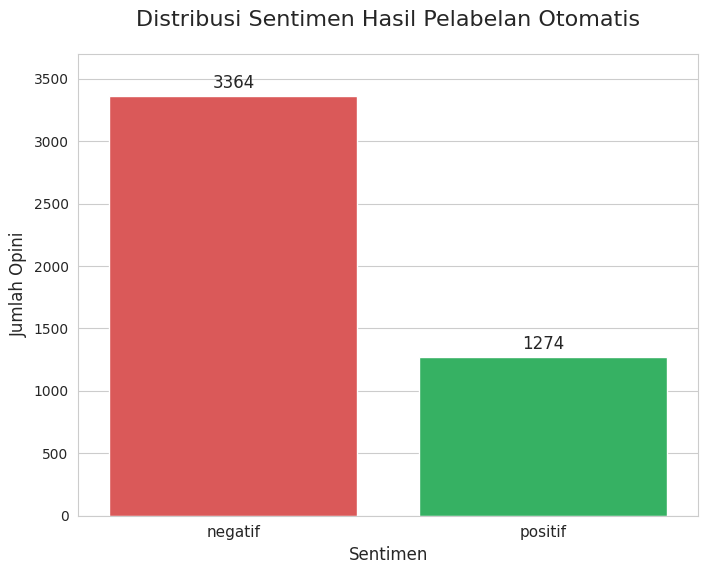


Jumlah data berdasarkan label otomatis:
auto_label
negatif    3364
positif    1274
Name: count, dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- LOAD DATA ---
nama_file = 'whoosh_labeled_2023_2024_2025.csv'

try:
    print(f"Sedang membaca file: {nama_file} ...")
    df_final = pd.read_csv(nama_file)
    print("File berhasil dimuat!")
except FileNotFoundError:
    print(f"Error: File '{nama_file}' tidak ditemukan. Cek nama file dan lokasinya.")
    # Stop eksekusi jika file tidak ada (opsional, tergantung environment)

# --- Visualisasi ---
print("\n--- Visualisasi Hasil Pelabelan Otomatis (Dari File) ---")

# Cek apakah kolom 'auto_label' ada di file
if 'auto_label' in df_final.columns:

    # Mengatur style plot agar terlihat lebih menarik
    sns.set_style("whitegrid")
    plt.figure(figsize=(8, 6))

    # Hitung jumlah sentimen
    auto_label_counts = df_final['auto_label'].value_counts()

    # Buat plot batang menggunakan Seaborn
    ax = sns.barplot(
        x=auto_label_counts.index,
        y=auto_label_counts.values,
        palette={'positif': '#22c55e', 'negatif': '#ef4444'}
    )

    # Tambahkan jumlah di atas setiap batang
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9), textcoords='offset points', fontsize=12)

    # Tambahkan judul dan label
    plt.title('Distribusi Sentimen Hasil Pelabelan Otomatis', fontsize=16, pad=20)
    plt.xlabel('Sentimen', fontsize=12)
    plt.ylabel('Jumlah Opini', fontsize=12)
    plt.xticks(fontsize=11)

    # Beri sedikit ruang di atas agar angka tidak terpotong
    plt.ylim(0, max(auto_label_counts.values) * 1.1)

    # Tampilkan plot
    plt.show()

    print("\nJumlah data berdasarkan label otomatis:")
    print(auto_label_counts)

else:
    print("Error: Kolom 'auto_label' tidak ditemukan di dalam file.")
    print("Kolom yang tersedia:", df_final.columns.tolist())

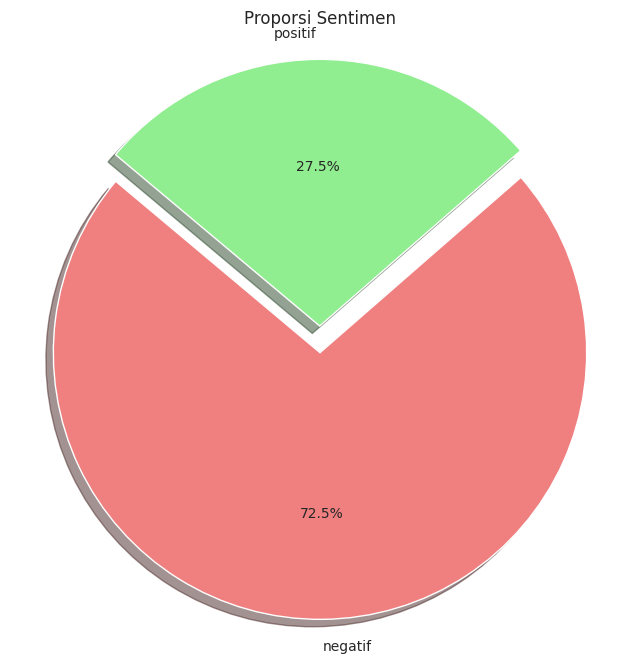


Visualisasi distribusi sentimen selesai.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# Pie Chart: Proporsi Sentimen
# ==============================================================================
sentiment_counts = df_final['final_label'].value_counts()
labels = sentiment_counts.index
sizes = sentiment_counts.values
colors = ['lightcoral', 'lightgreen'] # Warna untuk Positif dan Negatif
explode = (0.1, 0) # "Ledakan" sedikit irisan pertama (jika ada dua)

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Proporsi Sentimen')
plt.axis('equal') # Memastikan pie chart digambar sebagai lingkaran.
plt.show() # Tampilkan plot

print("\nVisualisasi distribusi sentimen selesai.")

sebelum ke tahap feature extraction, dataFrame di cek kembali secara manual, berikut hasil visualisasi diagram perbandingan sentimen positif dan negatif setelah dikoreksi manual

----------upload file 'label_cleaned_manual.csv' setelah run kode dibawah

In [ ]:
import pandas as pd
from google.colab import files

# Atur opsi tampilan agar output DataFrame rapi
pd.set_option('display.max_colwidth', 100)

# --- 1. UNGGAH FILE ---
print("Silakan unggah file 'label_cleaned_manual.csv' Anda.")
uploaded = files.upload()

# Dapatkan nama file yang baru saja diunggah
nama_file_manual = list(uploaded.keys())[0]

print(f"\n✅ Berhasil mengunggah file: '{nama_file_manual}'")

# --- 2. MUAT DATA DENGAN KONFIGURASI YANG TEPAT ---
# Konfigurasi: encoding='latin-1' (untuk karakter non-standar) dan sep=';' (untuk pemisah Titik Koma)
try:
    df_final = pd.read_csv(
        nama_file_manual,
        encoding='latin-1',
        sep=';'
    )

    print("\n[INFO] Berhasil dimuat menggunakan Encoding 'latin-1' dan Pemisah Titik Koma (';').")

    # --- 3. PERIKSA DATAFRAME BARU ANDA ---
    print("\nIni adalah data bersih yang siap untuk tahap Feature Extraction:")
    # Tampilkan beberapa baris dari kolom kunci
    print(df_final[['cleaned_text', 'final_label', 'auto_label']].head())
    print(f"\nJumlah total baris data: {df_final.shape[0]}")

except Exception as e:
    print(f"\n❌ Gagal memuat data. Error: {e}")

Silakan unggah file 'label_cleaned_manual.csv' Anda.


Saving label_cleaned_manual.csv to label_cleaned_manual.csv

✅ Berhasil mengunggah file: 'label_cleaned_manual.csv'

[INFO] Berhasil dimuat menggunakan Encoding 'latin-1' dan Pemisah Titik Koma (';').

Ini adalah data bersih yang siap untuk tahap Feature Extraction:
                                                                                          cleaned_text  \
0  kalo dipikir pikir aga absurd juga ya dari cgk mau ke bandung via keretaan harus pakai kak banda...   
1  orang malaysia mau liburan ke bandung malah disuruh landing di majalengka pantas sekarang pada m...   
2  2 transportasi publik modern mrt jakarta fase 1 lebak bulus bundaran hi lrt jabodebek kereta cep...   
3                                                                        kangen ke bandung naik whoosh   
4  lah kasus hambalang sudah selesai bego lu tersangkanya juga sudah di tangkap yang sekarang perlu...   

  final_label auto_label  
0     negatif    negatif  
1     negatif    negatif  
2     positif  


--- Visualisasi Hasil Setelah Koreksi Manual ---


/tmp/ipython-input-4151262325.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_final = sns.barplot(


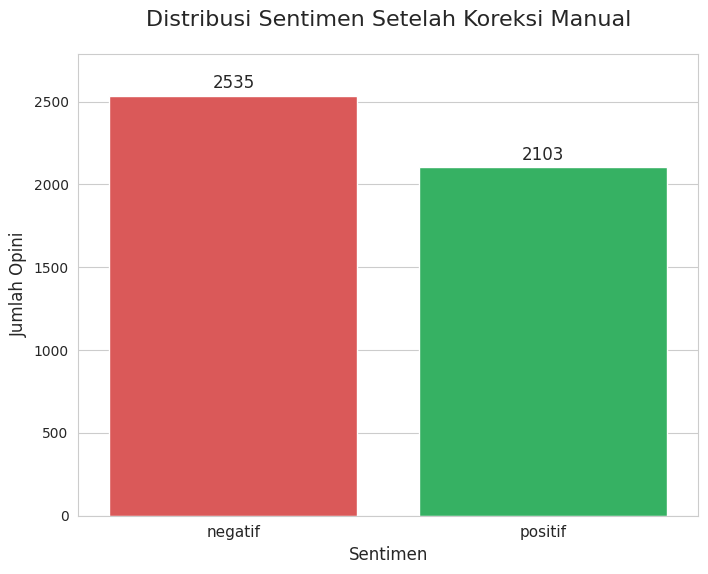


Jumlah data berdasarkan label final setelah koreksi:
final_label
negatif    2535
positif    2103
Name: count, dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Atur opsi tampilan agar output DataFrame rapi (sudah disarankan sebelumnya)
pd.set_option('display.max_colwidth', 100)

# PERBAIKAN: Membaca file dengan encoding dan delimiter yang sudah dikonfirmasi
try:
    df_final = pd.read_csv(
        nama_file_manual,
        encoding='latin-1',
        sep=';'
    )
except Exception as e:
    print(f"\n❌ Gagal memuat data. Error: {e}")
    # Jika gagal, tampilkan pesan error yang jelas dan hentikan visualisasi
    df_final = pd.DataFrame()

# --- Visualisasi Setelah Koreksi Manual ---
if not df_final.empty:
    # 1. FIX TYPO: Mengatasi error 'positfi' yang terdeteksi
    df_final['final_label'] = df_final['final_label'].replace({'positfi': 'positif'})

    print("\n--- Visualisasi Hasil Setelah Koreksi Manual ---")
    plt.figure(figsize=(8, 6))

    # Hitung jumlah sentimen dari kolom 'final_label'
    final_label_counts = df_final['final_label'].value_counts()

    # 2. HAPUS KATEGORI 'NETRAL'
    if 'netral' in final_label_counts.index:
        final_label_counts = final_label_counts.drop('netral')

    # Buat dictionary palette hanya untuk positif dan negatif
    custom_palette = {'positif': '#22c55e', 'negatif': '#ef4444'}

    # Buat plot batang
    ax_final = sns.barplot(
        x=final_label_counts.index,
        y=final_label_counts.values,
        palette=custom_palette
    )


    # Tambahkan jumlah di atas setiap batang
    for p in ax_final.patches:
        ax_final.annotate(
            f'{int(p.get_height())}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=12
        )

    # Tambahkan judul dan label
    plt.title('Distribusi Sentimen Setelah Koreksi Manual', fontsize=16, pad=20)
    plt.xlabel('Sentimen', fontsize=12)
    plt.ylabel('Jumlah Opini', fontsize=12)
    plt.xticks(fontsize=11)
    plt.ylim(0, max(final_label_counts.values) * 1.1)

    # Tampilkan plot
    plt.show()

    print("\nJumlah data berdasarkan label final setelah koreksi:")
    print(final_label_counts)

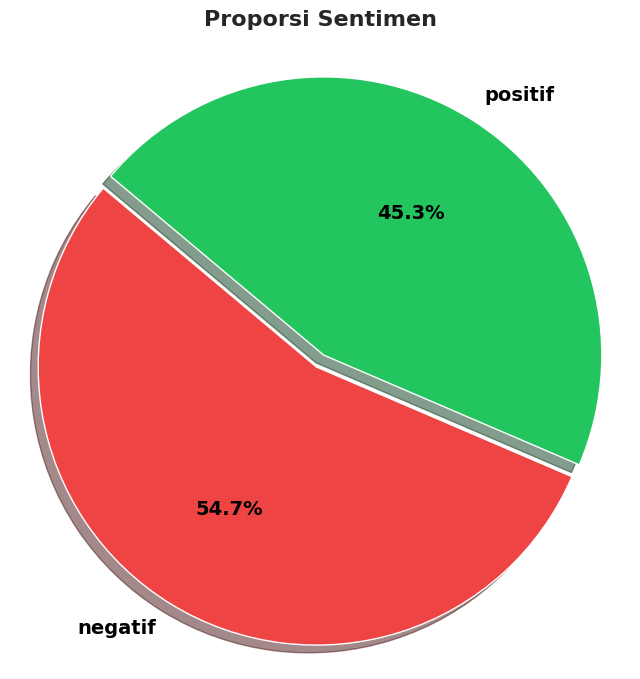


Visualisasi distribusi sentimen dengan teks tebal selesai.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# Pie Chart: Proporsi Sentimen (Versi Bold & Clean)
# ==============================================================================
sentiment_counts = df_final['final_label'].value_counts()
labels = sentiment_counts.index
sizes = sentiment_counts.values

# Menggunakan warna yang lebih kontras: Merah (Negatif) dan Hijau (Positif)
colors = ['#ef4444', '#22c55e']
explode = (0.05, 0) # Memberi jarak kecil antar irisan

plt.figure(figsize=(8, 8))

# Tambahkan textprops untuk membuat teks Bold dan memperbesar ukuran font
plt.pie(sizes,
        explode=explode,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        shadow=True,
        startangle=140,
        textprops={'fontsize': 14, 'weight': 'bold', 'color': 'black'})

# Membuat judul juga menjadi Bold
plt.title('Proporsi Sentimen', fontsize=16, fontweight='bold', pad=20)

plt.axis('equal')
plt.show()

print("\nVisualisasi distribusi sentimen dengan teks tebal selesai.")

Langkah 5: Feature Extraction (dengan IndoBERT)

FEATURE EXTRACTION - INDOBERT

In [ ]:
# lihat isi vocab indobert disertai token id
from transformers import AutoTokenizer

# Load tokenizer IndoBERT
tokenizer_indo = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

# 1. Melihat jumlah total kata di kamus IndoBERT
print(f"Total kata di kamus IndoBERT: {tokenizer_indo.vocab_size}")

# 2. Melihat 10 contoh isi kamus IndoBERT
vocab_indo = tokenizer_indo.get_vocab()
print("\nContoh isi kamus IndoBERT (Token: ID):")
# Kita ambil contoh yang isinya kata-kata bahasa Indonesia
example_tokens = list(vocab_indo.items())[5000:5010]
print(dict(example_tokens))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Total kata di kamus IndoBERT: 30521

Contoh isi kamus IndoBERT (Token: ID):
{'sengaja': 4380, 'kamp': 1857, 'menyumbang': 17914, '##untukkan': 14351, 'ufo': 24298, '##tad': 6030, '##onstruksi': 13941, '##iter': 1653, 'ki': 2236, 'botak': 22043}


In [ ]:
# Ganti 'df_selected' dengan 'df_final' karena pakai file uploaded final labeled

from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

# Muat tokenizer dan model IndoBERTtokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")
model = AutoModel.from_pretrained("indobenchmark/indobert-base-p1")

def extract_features(text):
    if not isinstance(text, str) or not text.strip():
        return np.zeros(768)
    # Tokenisasi teks
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=128)
    with torch.no_grad():
        # Dapatkan output dari model
        outputs = model(**inputs)
    # Ambil embedding dari token [CLS] (representasi seluruh kalimat)
    return outputs.last_hidden_state[:, 0, :].squeeze().numpy()


# Terapkan ekstraksi fitur
# Ini mungkin memakan waktu cukup lama jika datanya banyak
print("Memulai ekstraksi fitur dari data yang sudah dikoreksi secara manual...")
df_final['embeddings'] = df_final['cleaned_text'].apply(extract_features)

print("\n✅ Ekstraksi Fitur Selesai.")
df_final.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Memulai ekstraksi fitur dari data yang sudah dikoreksi secara manual...


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]


✅ Ekstraksi Fitur Selesai.


,text,created_at,cleaned_text,auto_label,confidence_score,final_label,embeddings
0,Kalo dipikir-pikir aga absurd juga ya. Dari cgk mau ke bandung via keretaan harus pake ka bandar...,Mon Oct 06 18:00:36 +0000 2025,kalo dipikir pikir aga absurd juga ya dari cgk mau ke bandung via keretaan harus pakai kak banda...,negatif,"9,91466E+15",negatif,"[1.3771105, 2.3670034, 0.0542067, 0.7698029, 2.283486, -1.3052278, -0.12763518, -0.99414814, 0.1..."
1,@Outstandjing Orang Malaysia mau liburan ke Bandung malah disuruh landing di Majalengka. Pantes ...,Mon Oct 06 15:32:13 +0000 2025,orang malaysia mau liburan ke bandung malah disuruh landing di majalengka pantas sekarang pada m...,negatif,"8,33255E+15",negatif,"[2.0059988, 3.4235823, 0.5972361, 0.8904368, 2.0314105, 0.5791167, 0.4382965, -0.94299895, -0.68..."
2,2. Transportasi Publik Modern * MRT Jakarta Fase 1 (Lebak Bulus Bundaran HI). * LRT Jabodebek. *...,Mon Oct 06 15:14:22 +0000 2025,2 transportasi publik modern mrt jakarta fase 1 lebak bulus bundaran hi lrt jabodebek kereta cep...,negatif,"5,92464E+15",positif,"[0.92010915, 1.8110808, 0.42992502, 0.34059927, 2.2265162, -2.4042754, -0.11963304, -1.2001864, ..."
3,Kangen ke bandung naik whoosh,Mon Oct 06 15:12:08 +0000 2025,kangen ke bandung naik whoosh,positif,"5,18526E+15",positif,"[0.94225585, 2.140967, 0.47621912, 0.34490153, 1.988862, -0.17846428, 0.1815672, -2.3264413, 0.0..."
4,@AnnaCharel27779 @NenkMonica Lah kasus Hambalang udah selesai begok lu tersangkanya juga udah di...,Mon Oct 06 14:57:55 +0000 2025,lah kasus hambalang sudah selesai bego lu tersangkanya juga sudah di tangkap yang sekarang perlu...,negatif,"6,05115E+15",negatif,"[0.96070397, 2.8237202, 0.08719678, 0.60268897, 2.4488094, -1.4730028, -0.27288213, -0.831808, 0..."


Langkah 6: Data Splitting & Scaling Feature

memisahkan fitur (X) dan label (y), membaginya menjadi data latih & uji, lalu melakukan scaling.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Pastikan df_final sudah ada dan berisi kolom 'embeddings' dan 'final_label'

# 1. Siapkan data X (fitur) dan y (label) dari DataFrame YANG BENAR
X = np.vstack(df_final['embeddings'].values)
y_labels = df_final['final_label'].values

# Encode label string menjadi angka (e.g., 'positif' -> 1, 'negatif' -> 0)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_labels)

# 2. Data Splitting (80% latih, 20% uji)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # stratify memastikan proporsi label sama di data latih & uji
)

# 3. Scaling Feature
# PENTING: Fit hanya pada data latih, lalu transform keduanya.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nUkuran Data Latih (X): {X_train_scaled.shape}")
print(f"Ukuran Data Uji (X): {X_test_scaled.shape}")
print(f"Jumlah Label Latih (y): {y_train.shape}")
print(f"Jumlah Label Uji (y): {y_test.shape}")


Ukuran Data Latih (X): (3710, 768)
Ukuran Data Uji (X): (928, 768)
Jumlah Label Latih (y): (3710,)
Jumlah Label Uji (y): (928,)


In [ ]:
import pandas as pd
import numpy as np

# 1. Deteksi kolom teks secara otomatis
text = df_final.select_dtypes(include=['object']).columns[0]

# 2. Ambil data sampel (baris pertama)
teks_asli = df_final.iloc[0][text]

# 3. Hitung statistik asli dari data (untuk kolom statistik)
mean_ori = X_train.mean()
std_ori = X_train.std()
mean_scaled = X_train_scaled.mean()
std_scaled = X_train_scaled.std()

# 4. Ambil sampel vektornya
vektor_ori = X_train[0][:5].round(2).tolist()
vektor_scaled = X_train_scaled[0][:5].round(2).tolist()

# 5. Buat tabel dengan kondisi YANG SEBENARNYA
df_gabungan = pd.DataFrame({
    'Komponen Analisis': [
        'Data Teks (Input)',
        'Original Embedding',
        'After Scaling'
    ],
    'Isi Data / Nilai Vektor (5 Dimensi Awal)': [
        f'"{teks_asli[:100]}..."',
        vektor_ori,
        vektor_scaled
    ],
    'Kondisi Statistik Riil': [
        '-',
        f'Mean: {mean_ori:.2f}, Std: {std_ori:.2f}', # Sesuai data asli
        f'Mean: {mean_scaled:.1f}, Std: {std_scaled:.1f}' # Pasti 0.0 dan 1.0
    ]
})

print("--- TABEL ANALISIS DATA REAL (UNTUK PPT) ---")
display(df_gabungan)

--- TABEL ANALISIS DATA REAL (UNTUK PPT) ---


,Komponen Analisis,Isi Data / Nilai Vektor (5 Dimensi Awal),Kondisi Statistik Riil
0,Data Teks (Input),"""Kalo dipikir-pikir aga absurd juga ya. Dari cgk mau ke bandung via keretaan harus pake ka banda...",-
1,Original Embedding,"[0.36000001430511475, 1.7799999713897705, 0.6499999761581421, 1.0299999713897705, 2.230000019073...","Mean: 0.00, Std: 1.01"
2,After Scaling,"[-0.9800000190734863, -0.5799999833106995, 0.5699999928474426, 1.0099999904632568, -0.5299999713...","Mean: -0.0, Std: 1.0"


Langkah 7: Training Model & Evaluation

In [ ]:
# Impor library tambahan yang dibutuhkan
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

XGBoost dan SGDClassifier

In [ ]:
from xgboost import XGBClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report

# Siapkan model yang akan digunakan
models = {
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "SGDClassifier": SGDClassifier(loss='log_loss', penalty='l2', alpha=1e-3, random_state=42, max_iter=1000, tol=1e-3)
}

# Buat dictionary baru untuk menyimpan hasil
results = {}

# Latih dan evaluasi setiap model
for name, model in models.items():
    print(f"--- Melatih dan Mengevaluasi Model: {name} ---")

    # Training
    model.fit(X_train_scaled, y_train)

    # Prediksi pada data uji
    y_pred = model.predict(X_test_scaled)

    # Evaluation
    print("Laporan Klasifikasi:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

    # Simpan hasil ke dictionary BARU
    results[name] = {'model': model, 'y_pred': y_pred}
    print("\n")

print("✅ Pelatihan dan evaluasi semua model selesai.")

--- Melatih dan Mengevaluasi Model: XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:59:25] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Laporan Klasifikasi:
              precision    recall  f1-score   support

     negatif       0.78      0.82      0.80       507
     positif       0.77      0.71      0.74       421

    accuracy                           0.77       928
   macro avg       0.77      0.77      0.77       928
weighted avg       0.77      0.77      0.77       928



--- Melatih dan Mengevaluasi Model: SGDClassifier ---
Laporan Klasifikasi:
              precision    recall  f1-score   support

     negatif       0.78      0.75      0.76       507
     positif       0.71      0.74      0.73       421

    accuracy                           0.75       928
   macro avg       0.74      0.75      0.74       928
weighted avg       0.75      0.75      0.75       928



✅ Pelatihan dan evaluasi semua model selesai.


Akurasi, Presisi, Recall, dan F1-Score

--- Laporan Klasifikasi untuk: XGBoost ---
              precision    recall  f1-score   support

     negatif       0.78      0.82      0.80       507
     positif       0.77      0.71      0.74       421

    accuracy                           0.77       928
   macro avg       0.77      0.77      0.77       928
weighted avg       0.77      0.77      0.77       928



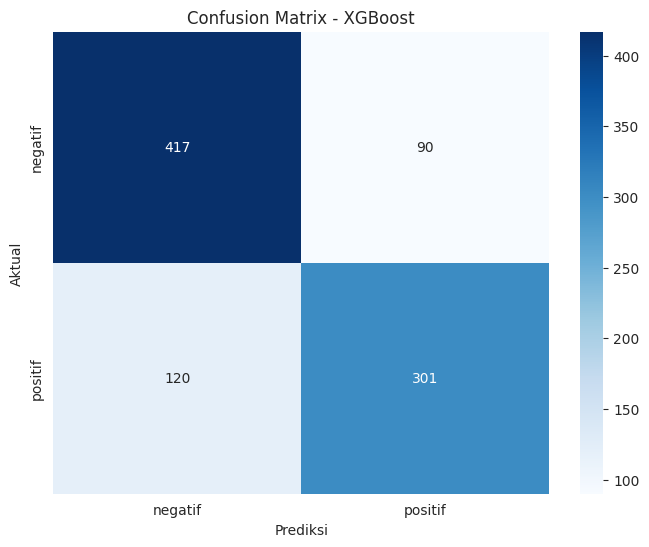



--- Laporan Klasifikasi untuk: SGDClassifier ---
              precision    recall  f1-score   support

     negatif       0.78      0.75      0.76       507
     positif       0.71      0.74      0.73       421

    accuracy                           0.75       928
   macro avg       0.74      0.75      0.74       928
weighted avg       0.75      0.75      0.75       928



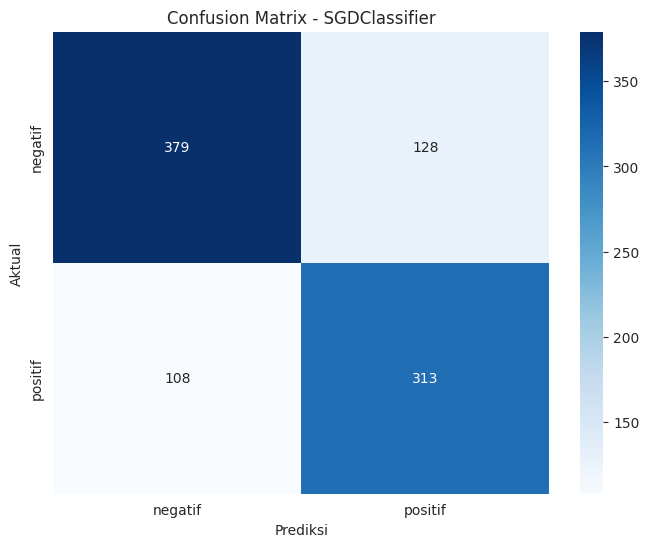



--- Tabel Perbandingan Kinerja Model ---
        Model Akurasi Presisi (Macro) Recall (Macro) F1-Score (Macro)
      XGBoost  77.37%          77.32%         76.87%           77.01%
SGDClassifier  74.57%          74.40%         74.55%           74.44%


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# confusion matrix
def plot_confusion_matrix(y_true, y_pred, title, labels):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.title(title)
    plt.show()


# --- Evaluasi Lanjutan dan Perbandingan Model ---

# Siapkan list untuk menyimpan hasil
evaluation_results = []

# Loop melalui 'results', bukan 'models'
for name, model_info in results.items():
    # model = model_info['model'] # baris ini tidak diperlukan untuk evaluasi metrik
    y_pred = model_info['y_pred']

    # Hitung metrik evaluasi utama
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    # Simpan hasil
    evaluation_results.append({
        "Model": name,
        "Akurasi": f"{accuracy:.2%}",
        "Presisi (Macro)": f"{precision:.2%}",
        "Recall (Macro)": f"{recall:.2%}",
        "F1-Score (Macro)": f"{f1:.2%}"
    })

    # Tampilkan Laporan Klasifikasi Rinci
    print(f"--- Laporan Klasifikasi untuk: {name} ---")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

    # Tampilkan Confusion Matrix
    plot_confusion_matrix(y_test, y_pred,
                          title=f'Confusion Matrix - {name}',
                          labels=label_encoder.classes_)
    print("\n" + "="*60 + "\n")


# Buat DataFrame untuk perbandingan kinerja model
df_evaluation = pd.DataFrame(evaluation_results)

print("--- Tabel Perbandingan Kinerja Model ---")
# .to_string() memastikan semua kolom ditampilkan dengan rapi
print(df_evaluation.to_string(index=False))

Langkah 8: Visualization

In [ ]:
!pip install wordcloud -q

In [ ]:
# Impor library tambahan yang dibutuhkan
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


--- Visualisasi: Word Cloud ---


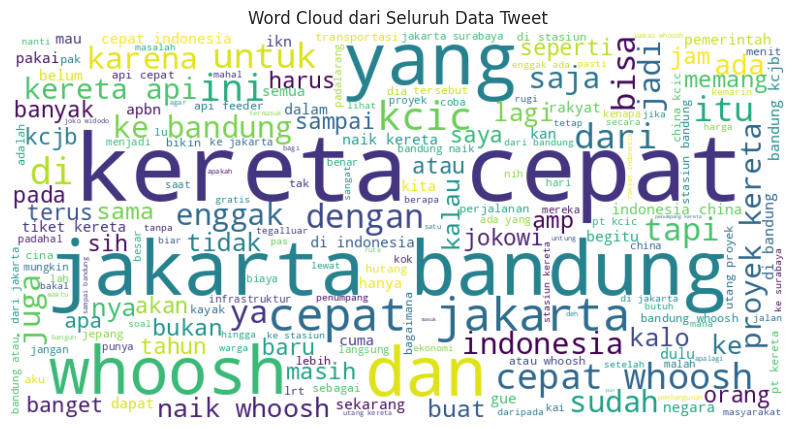

In [ ]:
# --- Word Cloud ---
print("\n--- Visualisasi: Word Cloud ---")

# <-- Gunakan 'df_final' bukan 'df' -->
# --- Word Cloud Semua Teks ---
all_text = ' '.join(df_final['cleaned_text'])
wordcloud_all = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10, 8))
plt.imshow(wordcloud_all, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud dari Seluruh Data Tweet')
plt.show()


--- Visualisasi: Word Cloud Sentimen (Analisis Mendalam) ---


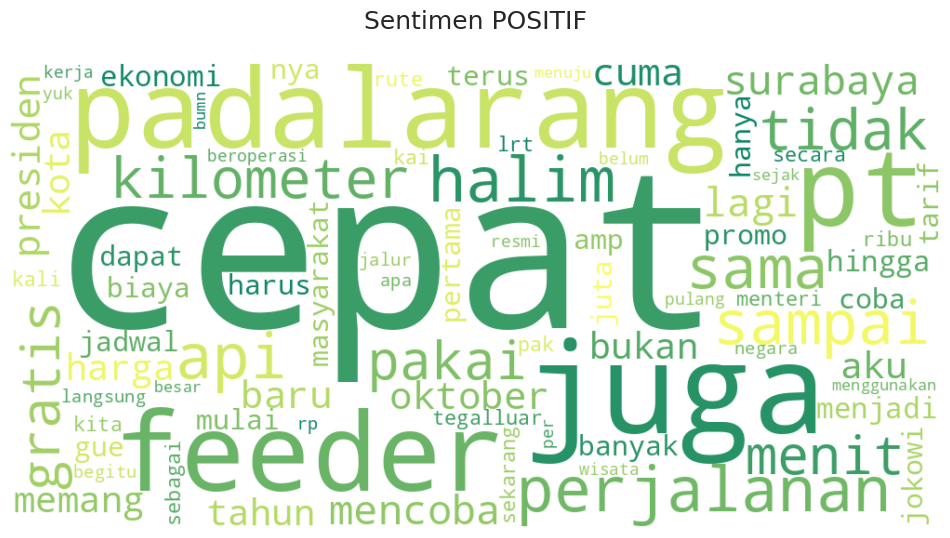

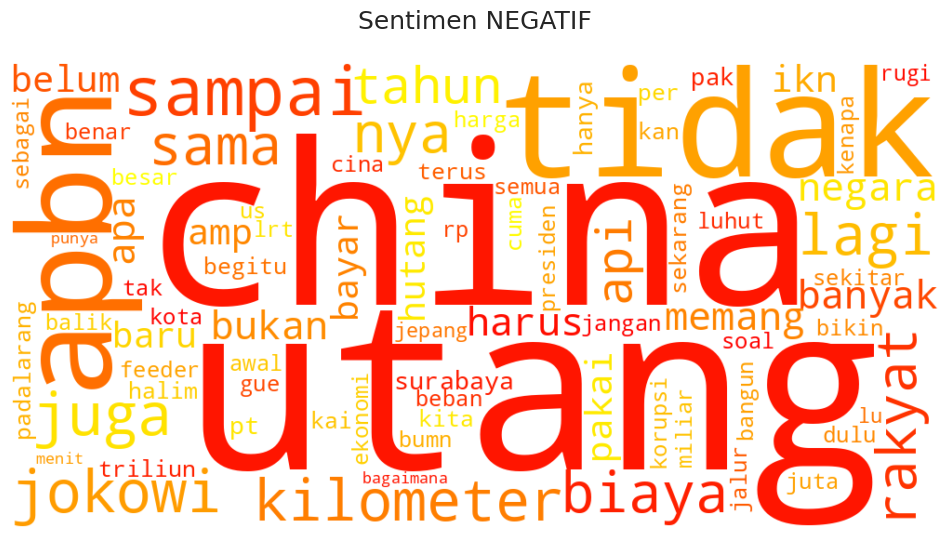

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. Daftar Stopwords Dasar (Dibuang dari Semua Label)
# ----------------------------------------------------

proyek_stopwords = {
    'kereta', 'whoosh', 'jakarta', 'bandung', 'indonesia', 'kcic',
    'kcjb', 'stasiun', 'penumpang', 'transportasi', 'proyek', 'pemerintah',
    'tiket', 'naik', 'jalan', 'hari', 'jam', 'waktu', 'hal', 'orang'
}

formal_indo = {
    'yang', 'untuk', 'pada', 'ke', 'dari', 'dengan', 'adalah', 'akan', 'atau','enggak',
    'telah', 'sudah', 'tapi', 'namun', 'bahwa', 'oleh', 'saat', 'dalam', 'bagi','karena',
    'serta', 'seperti', 'ia', 'kami', 'kamu', 'saya', 'anda', 'mereka', 'dia',
    'dan','lebih','mau'
}

slang_stopwords = {
    'aja', 'saja', 'ya', 'gak', 'nggak', 'udah', 'bisa', 'jadi', 'buat',
    'ada', 'kalau', 'kalo', 'masih', 'nih', 'si', 'kok', 'loh', 'deh', 'pun',
    'banget', 'kayak', 'sih', 'lah', 'gitu', 'gini', 'emang', 'pantes', 'padahal',
    'mo', 'tuh', 'biar', 'lalu', 'is', 'the', 'and', 'di', 'ini', 'itu', 'malah'
}

# Base stopwords gabungan
base_stopwords = STOPWORDS.union(proyek_stopwords).union(formal_indo).union(slang_stopwords)

# ----------------------------------------------------
# 2. Fungsi Generator Word Cloud dengan Filter Custom
# ----------------------------------------------------
def generate_wordcloud(text, title, colormap, extra_stopwords=None):
    if not text.strip():
        print(f"Peringatan: Tidak ada teks untuk {title}")
        return

    # Gabungkan base stopwords dengan extra jika ada
    final_stopwords = base_stopwords.copy()
    if extra_stopwords:
        final_stopwords = final_stopwords.union(extra_stopwords)

    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color='white',
        colormap=colormap,
        stopwords=final_stopwords,
        max_words=80,
        min_font_size=10,
        collocations=False
    ).generate(text)

    plt.figure(figsize=(12, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=18, pad=25)
    plt.show()

# ----------------------------------------------------
# 3. Eksekusi dengan Filter Berbeda
# ----------------------------------------------------
print("\n--- Visualisasi: Word Cloud Sentimen (Analisis Mendalam) ---")

# Ambil teks untuk masing-masing sentimen
pos_text = ' '.join(df_final[df_final['final_label'] == 'positif']['cleaned_text'])
neg_text = ' '.join(df_final[df_final['final_label'] == 'negatif']['cleaned_text'])

# A. Word Cloud POSITIF (Buang kata 'utang' & 'mahal' agar fokus ke layanan)
pos_extra = {'utang', 'hutang', 'apbn', 'mahal','china'}
generate_wordcloud(pos_text, 'Sentimen POSITIF', 'summer', extra_stopwords=pos_extra)

# B. Word Cloud NEGATIF (Buang kata bernada positif hasil sarkasme, tapi 'utang' biarkan muncul)
neg_extra = {'keren', 'mantap', 'bangga', 'bagus','cepat'}
generate_wordcloud(neg_text, 'Sentimen NEGATIF', 'autumn', extra_stopwords=neg_extra)

Kode untuk Menyimpan dan Mengunduh Model di Colab

In [ ]:
import joblib
from google.colab import files

# --- 1. SIMPAN SEMUA OBJEK KE FILE .pkl ---

# Nama file yang akan dibuat
nama_file_xgb = 'xgboost_model.pkl'
nama_file_sgd = 'sgd_model.pkl'
nama_file_scaler = 'scaler.pkl'
nama_file_encoder = 'label_encoder.pkl'

# --- Ambil model yang sudah dilatih dari dictionary 'results' ---
joblib.dump(results['XGBoost']['model'], nama_file_xgb)
joblib.dump(results['SGDClassifier']['model'], nama_file_sgd)

# Variabel scaler dan label_encoder sudah benar
joblib.dump(scaler, nama_file_scaler)
joblib.dump(label_encoder, nama_file_encoder)

print(f"✅ Berhasil menyimpan 4 file: {nama_file_xgb}, {nama_file_sgd}, {nama_file_scaler}, {nama_file_encoder}")
print("\nMemulai proses unduh...")

# --- 2. UNDUH FILE-FILE TERSEBUT KE KOMPUTER ---
files.download(nama_file_xgb)
files.download(nama_file_sgd)
files.download(nama_file_scaler)
files.download(nama_file_encoder)

print("\nProses unduh selesai. Silakan periksa folder unduhan di browser Anda.")

✅ Berhasil menyimpan 4 file: xgboost_model.pkl, sgd_model.pkl, scaler.pkl, label_encoder.pkl

Memulai proses unduh...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Proses unduh selesai. Silakan periksa folder unduhan di browser Anda.


**Sentiment Analysis WHOOSH - Connect to Looker Studio**

In [ ]:
from google.colab import auth
import gspread
from google.auth import default
import pandas as pd

# 1. Autentikasi
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# 2. Buka file Google Sheets yang sudah ada di Drive
# Masukkan nama file yang tepat: 'DATASET WHOOSH'
ss = gc.open('DATASET WHOOSH')

# 3. Pilih sheet berdasarkan nama yang kamu sebutkan tadi
worksheet = ss.worksheet('label_cleaned_manual')

# 4. Ambil semua data dan ubah ke Pandas DataFrame
data = worksheet.get_all_values()
df_hasil = pd.DataFrame(data[1:], columns=data[0])

# Cek apakah data sudah terbaca dengan benar
df_hasil.head()

Sebenernya bisa pake sheet diatas langsung, cuma klo semisal mau dipindah sheet pake cara berikut

In [ ]:
from google.colab import auth
import gspread
from google.auth import default

# 1. Autentikasi
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# 2. Buat file baru untuk dashboard (agar data asli skripsi tetap aman/tidak teracak-acak)
sh = gc.create('Dashboard_Sentimen_Whoosh_Galardhia')
worksheet = sh.get_worksheet(0)

# 3. Kirim data ke Sheets
# .fillna('') ditambahkan agar data yang kosong tidak menyebabkan error saat ekspor
df_bersih = df_hasil.fillna('')
worksheet.update([df_bersih.columns.values.tolist()] + df_bersih.values.tolist())

print(f"Berhasil! Data siap diakses di Looker Studio melalui link ini: {sh.url}")

Berhasil! Data siap diakses di Looker Studio melalui link ini: https://docs.google.com/spreadsheets/d/1kL9dINxv1p5mDUiIEncCDOdM5KtoPo_H36wAims78oQ
